# Tareas con los datos nuevos
- quitar los spills
- rehacer los plots sin los spills
- hacer la resta bkg+sig-bkg (bin a bin)
- scatter y sacar conclusiones de todo esto



In [2]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

pltext.style()

In [3]:
datapath = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/"    #ahora los csv están en mi carpeta
filename_bkg = "1766_uncut_15kevents.csv"
data_bkg     = pd.read_csv(datapath+filename_bkg)

filename_sig = "1767_uncut_15kevents.csv"
data_sig     = pd.read_csv(datapath+filename_sig)


In [4]:
data_bkg

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids
0,0.0,76264.181597,79.0,27.0,2.0,9.0,3.0
1,0.0,76273.067467,209.0,118.0,55.0,3.0,18.0
2,1.0,209221.084343,103.0,114.0,19.0,13.0,12.0
3,1.0,209223.152791,119.0,114.0,19.0,12.0,4.0
4,1.0,209233.144440,175.0,114.0,19.0,10.0,10.0
...,...,...,...,...,...,...,...
1433051,201316.0,459565.065760,111.0,97.0,92.0,1.0,6.0
1433052,201316.0,459565.813249,82.0,94.0,11.0,6.0,8.0
1433053,201316.0,459568.619830,164.0,32.0,75.0,8.0,9.0
1433054,201317.0,461939.606112,372.0,114.0,19.0,3.0,18.0


In [5]:
data_sig

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids
0,0.0,53683.787124,117.0,108.0,3.0,14.0,13.0
1,0.0,53691.537798,100.0,102.0,22.0,10.0,10.0
2,1.0,63479.663380,83.0,12.0,1.0,15.0,5.0
3,1.0,63480.392541,133.0,36.0,46.0,13.0,12.0
4,1.0,63496.106182,180.0,96.0,8.0,15.0,5.0
...,...,...,...,...,...,...,...
3361704,455342.0,492800.972765,237.0,78.0,33.0,11.0,11.0
3361705,455342.0,492801.767311,123.0,85.0,93.0,4.0,1.0
3361706,455342.0,492801.914035,140.0,20.0,81.0,17.0,15.0
3361707,455342.0,492802.180405,221.0,100.0,24.0,2.0,0.0


El proceso es el siguiente:

$^{252}\text{Cf}\rightarrow ^{148}\text{Ba}+^{106}\text{Mo}+4n$

$^{58}\text{Ni}+n\rightarrow ^{59}\text{Ni}+\gamma$

Los fotones son los que se detectan, vemos que en este run detectamos 1433056 fotones (hits) de background. Para organizar esta gigantesca información definimos los "eventos", que corresponden a la toma de datos en un intervalo de tiempo de 500 microsegundos(??), cada uno con un número variable de fotones que llegan al WCTE. Indexamos los eventos con el event_id. En estos eventos debemos separar el "ruido" de los candidates (fotones registrados que provienen del decay del $^{58}\text{Ni}$).

Como me interesan los eventos agrupo los hits en su evento correspindiente con .groupby. Sumo hit_pmt_charges (carga total en cada evento), cuento cuántos hits tiene cada evento (cuántos fotones tiene cada evento), y la RMS del tiempo (si trms es pequeña los hits han llegado casi al mismo tiempo al PMT en este evento).

In [21]:
data_by_event_bkg=data_bkg.groupby("event_id")

total_charge_by_event_bkg = data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size() #.size() devuelve el nº de elementos, osea el nº de hits en cada evento
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std() #.std() ya lo calcula q facil, pero por q se le llama total_trms?? No hay solo una?

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()

Hemos almacenado la carga total por evento, el nº de hits por evento y la trms por evento en series: total_charge_by_event_bkg, total_nhits_by_event_bkg, total_trms_by_event_bkg (igual para los datos de señal). Ahora hacemos un gráfico de dispersión (scatter plot, no une los puntos) de cada serie frente el índice que indexa cada evento.

plt.scatter(x.index, y.values) ; .index indexa los elementos de la serie y coge los índices, .values da los valores

Text(0.5, 0.98, 'Carga total de cada candidate vs nº de candidate')

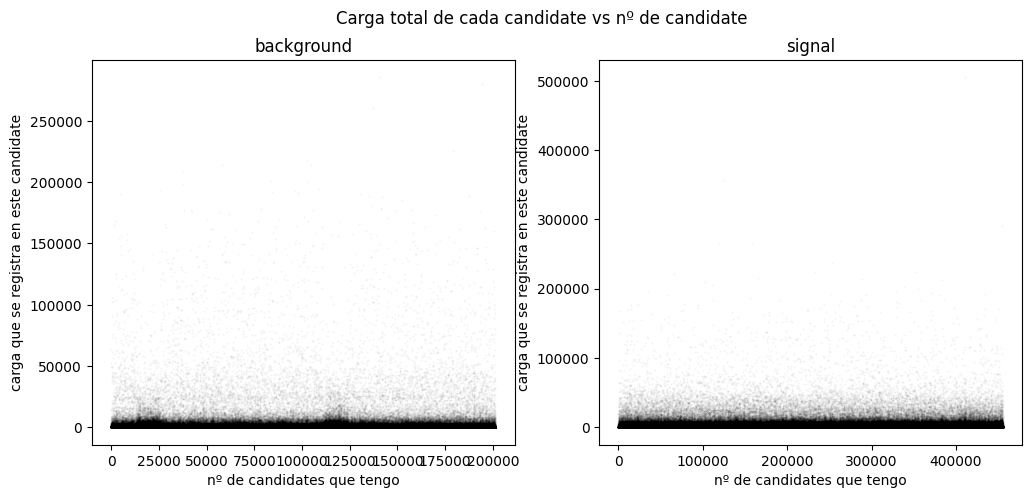

In [19]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("signal")

plt.suptitle("Carga total de cada candidate vs nº de candidate")

Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

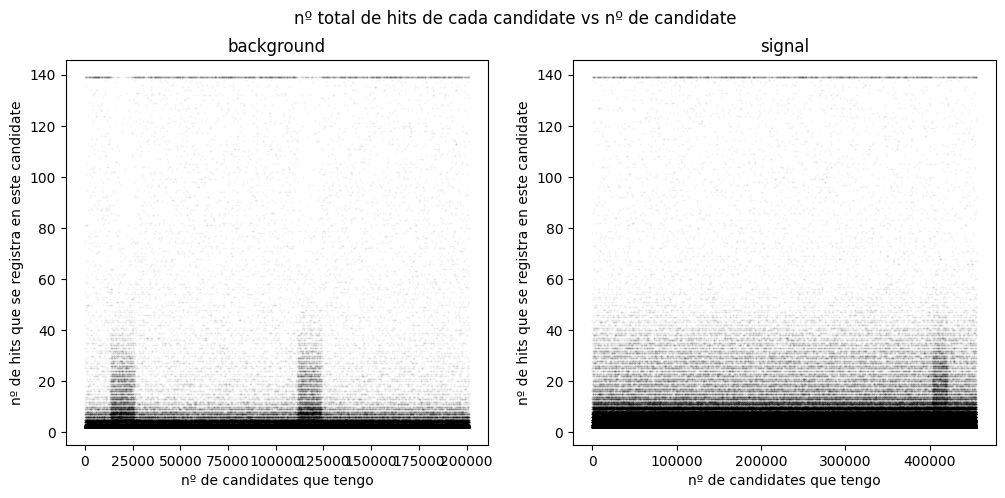

In [20]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

In [146]:
#ahora quiero quitar los spills y los que saturan

#lo lógico primero es bucar cuál es el valor exacto de saturación:
max_value_of_total_nhits_by_event_bkg = total_nhits_by_event_bkg.max()  #aquí .max() va con () porque realiza un cálculo
print(f"{max_value_of_total_nhits_by_event_bkg} es el valor al que satura el nº de hits en los candidates para bkg")

#ahora quiero agrupar los eventos en los que este valor satura, filtrando los eventos en los que total_nhits_by_event_bkg coincida (==) con max_value_of_total_nhits_by_event_bkg
events_saturating = total_nhits_by_event_bkg[total_nhits_by_event_bkg == max_value_of_total_nhits_by_event_bkg]
print(f"{events_saturating.size} eventos de bkg que saturan a este valor") #ojo! sin ()

#ahora quiero quitar estos eventos:

#total_nhits_by_event_bkg_without_saturation = total_nhits_by_event_bkg - events_saturating
#esto no funciona xq son series de pandas
#uso mejor .drop(x), que elimina el índice x de una serie

indices_saturating = events_saturating.index
print(indices_saturating)
clean_series_0 = total_nhits_by_event_bkg.drop(indices_saturating)    #serie sin los valores que saturan

139 es el valor al que satura el nº de hits en los candidates para bkg
1888 eventos de bkg que saturan a este valor
Index([    57.0,    182.0,    443.0,    593.0,    651.0,    666.0,    670.0,
          678.0,    777.0,    877.0,
       ...
       200196.0, 200348.0, 200659.0, 200871.0, 200887.0, 200913.0, 201052.0,
       201076.0, 201193.0, 201249.0],
      dtype='float64', name='event_id', length=1888)


Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

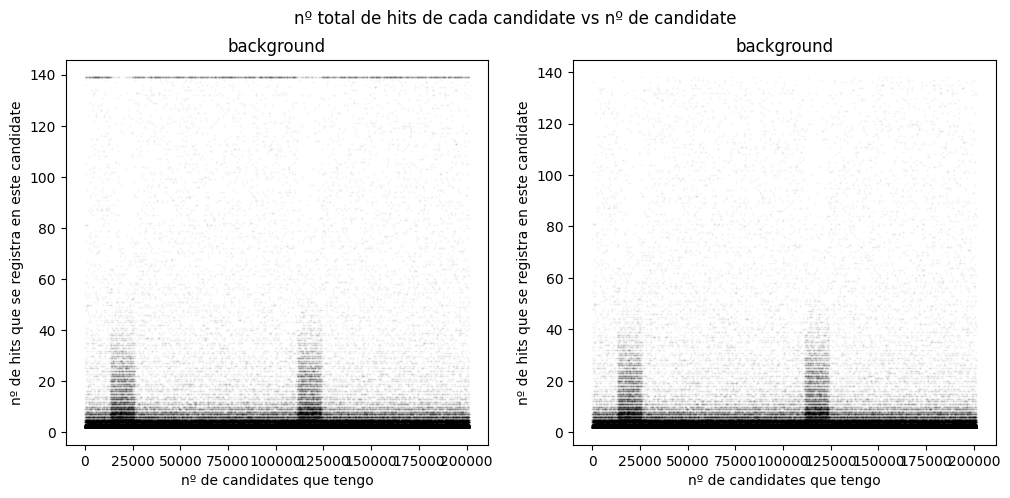

In [147]:
subplot = pltext.canvas(2)      #scattereo las dos (con y sin candidates saturantes) para verlo bien

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(clean_series_0.index, clean_series_0.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

(105000.0, 130000.0)

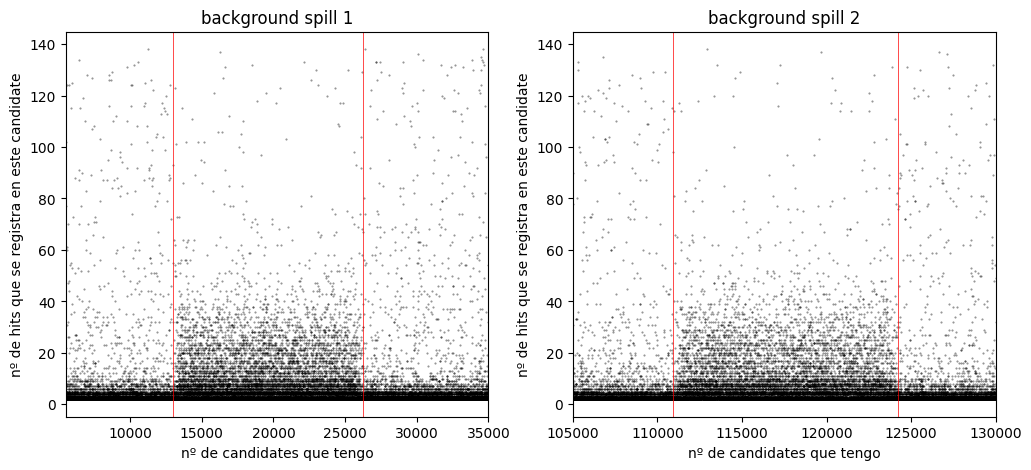

In [145]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(clean_series_0.index, clean_series_0.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background spill 1")

x_lines_spill1 = [13000, 26250]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill1:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(5500, 35000)
#plt.ylim(0,140)

subplot(2)
plt.scatter(clean_series_0.index, clean_series_0.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background spill 2")

x_lines_spill2 = [110900, 124250]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill2:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(105000, 130000)
#plt.ylim(0,140)

Text(0.5, 1.0, 'background')

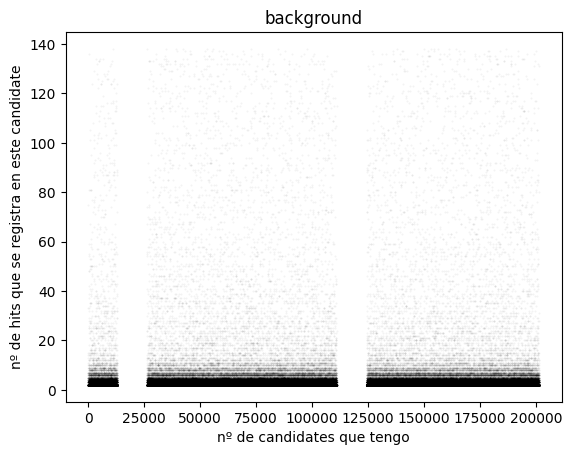

In [169]:
x_min_s1 = 13000; x_max_s1 = 26250
x_min_s2 = 110900; x_max_s2 = 124250

#series que hay que quitar
clean_series_1 = clean_series_0[(clean_series_0.index >= x_min_s1) & (clean_series_0.index <= x_max_s1)]
clean_series_2 = clean_series_0[(clean_series_0.index >= x_min_s2) & (clean_series_0.index <= x_max_s2)]

#hay que concatenar sus índices, NO SUMAR
combined_indices = pd.concat([clean_series_1, clean_series_2]).index

clean_series_total = clean_series_0.drop(combined_indices)

plt.scatter(clean_series_total.index, clean_series_total.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

In [168]:
clean_series_1

Series([], dtype: int64)

(0.0, 140.0)

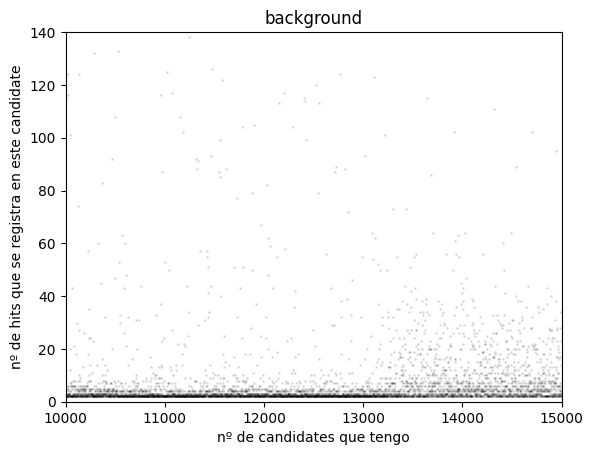

In [67]:
plt.scatter(clean_series.index, clean_series.values, s=1, alpha=0.1)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background spill 1")

plt.xlim(10000, 15000)
plt.ylim(0,140)

Text(0.5, 0.98, 'trms de cada candidate vs nº de candidate')

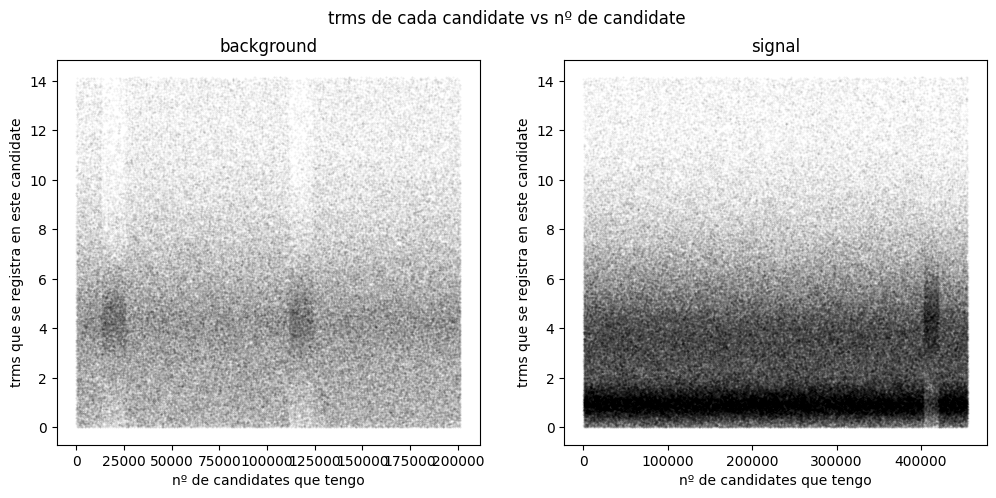

In [24]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("signal")

plt.suptitle("trms de cada candidate vs nº de candidate")

Text(0.5, 1.0, 'signal')

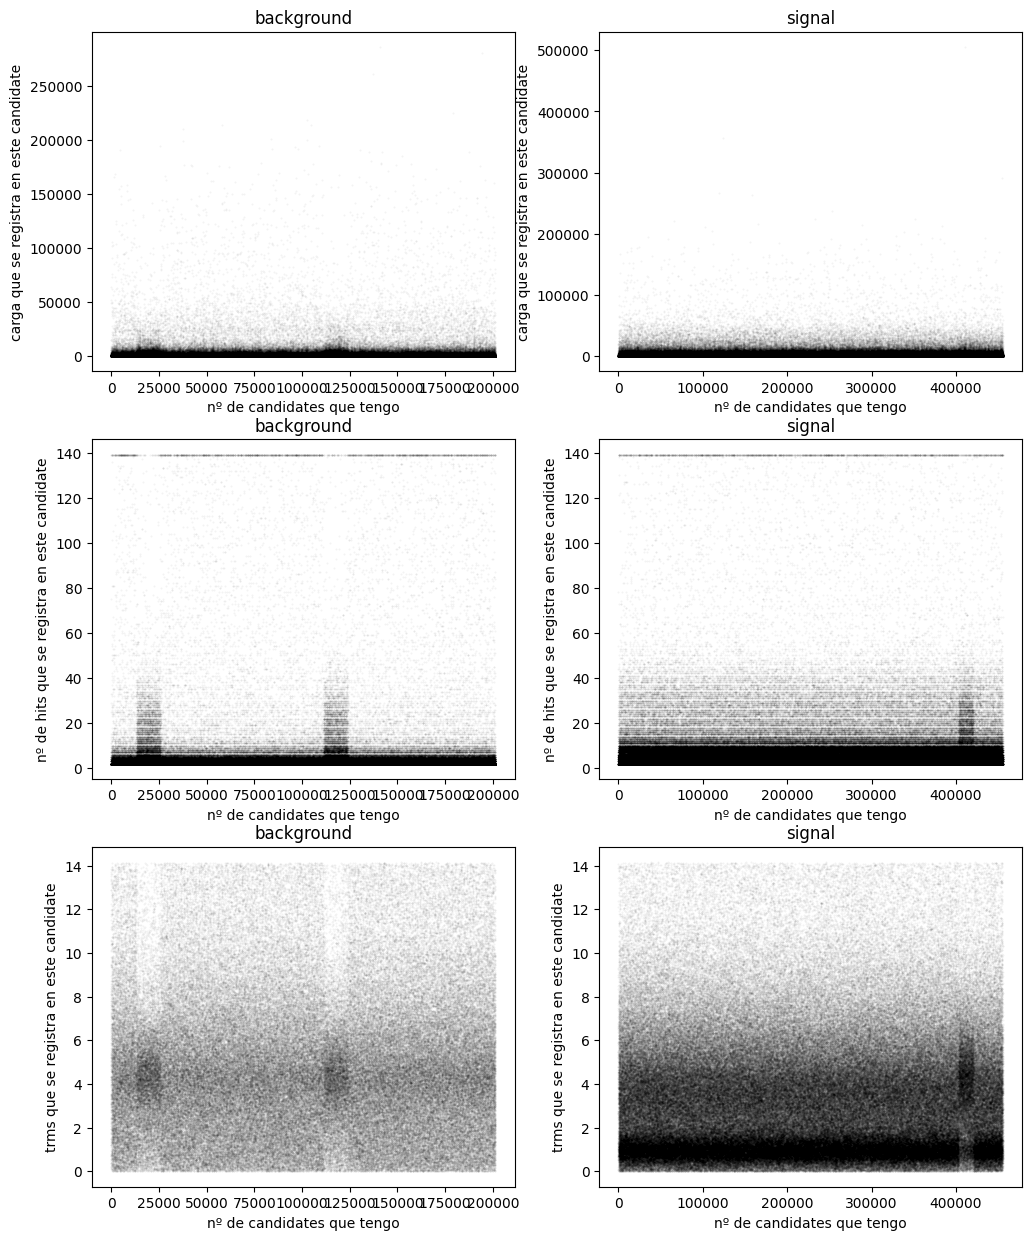

In [26]:
#lo pongo todo junto:

subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("signal")

subplot(3)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(4)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("background")

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("signal")

In [ ]:
#data_bkg = data_bkg[(data_bkg["event_id"].values < 300e3) & (data_bkg["event_id"].values > 150e3)]
#data_sig = data_sig[(data_sig["event_id"].values < 0.4e6) & (data_sig["event_id"].values > 0)]

In [20]:
data_by_event_bkg=data_bkg.groupby("event_id")
total_charge_by_event_bkg=data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size()
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std()

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()
#######################################################################
# #la columna hit_pmt_charges de cada grupo y luego sumamos sus valores
# print(total_charge_by_event)

# #==============CHATTY===========================================
# # Busco los 30 eventos con más hits
# top_30_charge=total_charge_by_event.nlargest(30) #crea una serie con los 30 valores más grandes de total_charge_by_event

# print("="*60)
# print("TOP 30 EVENTOS CON MÁS CARGA TOTAL")
# print("="*60)

# # Convertir a DataFrame con ranking desde 1
# top_30_df = top_30_charge.reset_index()
# top_30_df.columns = ['event_id', 'carga total']
# top_30_df.index = top_30_df.index + 1
# top_30_df.index.name = 'ranking'

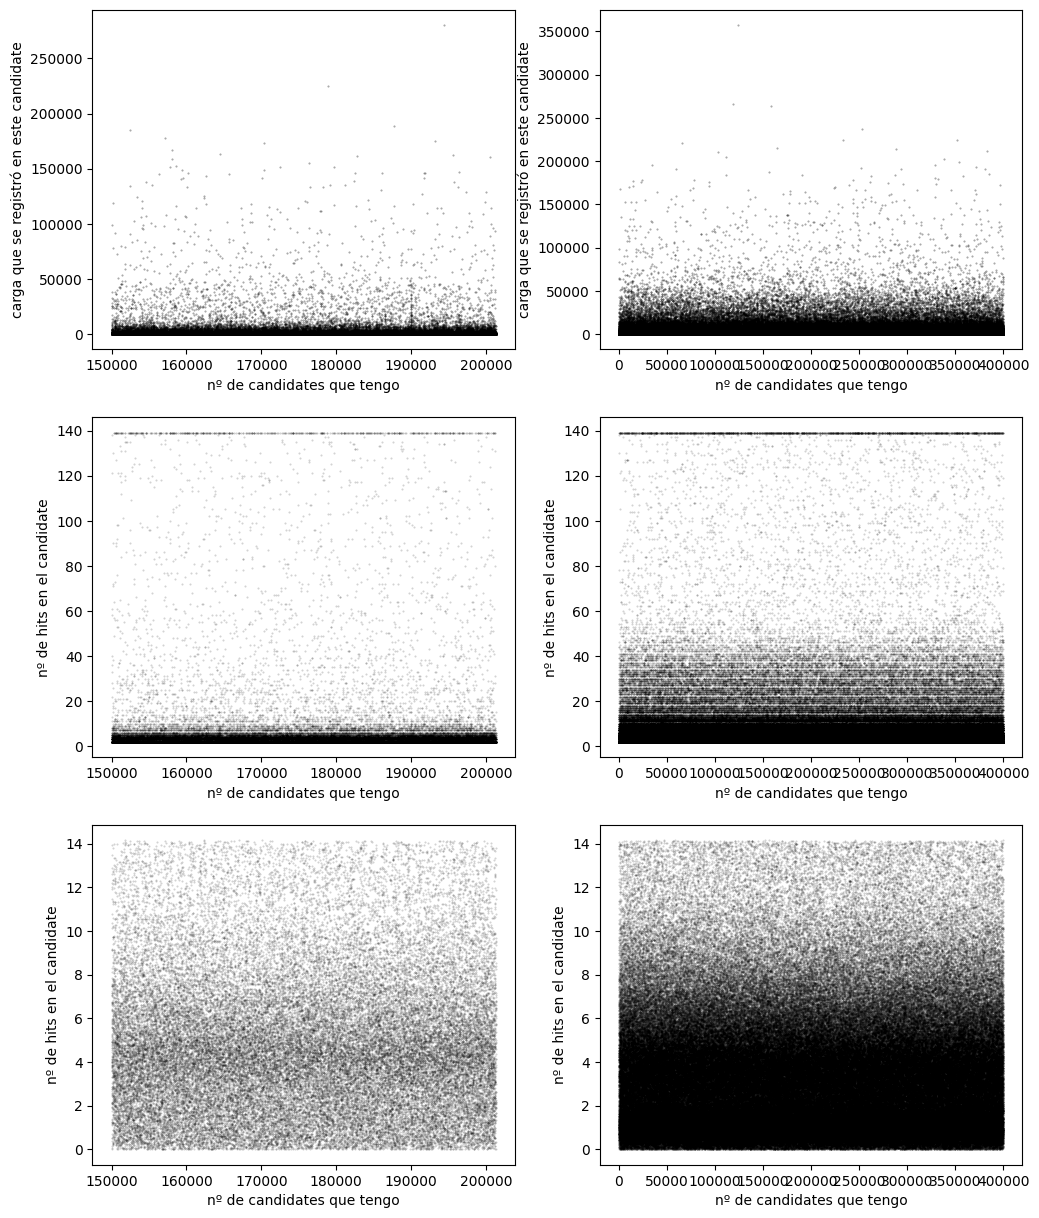

In [ ]:
subplot = pltext.canvas(6)  #ME DESAPARECEN LOS SPILLS??

subplot(1)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.4)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registró en este candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
#plt.ylim(0, 50e3); 

subplot(2)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.4)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registró en este candidate")
#plt.ylim(0, 50e3);

subplot(3)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(4)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

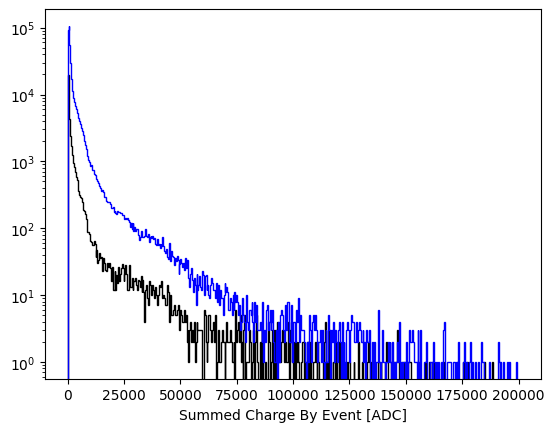

In [13]:
plt.hist(total_charge_by_event_bkg, 500, histtype="step", range=(0, 200e3));
plt.hist(total_charge_by_event_sig, 500, histtype="step", range=(0, 200e3));
plt.xlabel("Summed Charge By Event [ADC]");
plt.yscale("log");

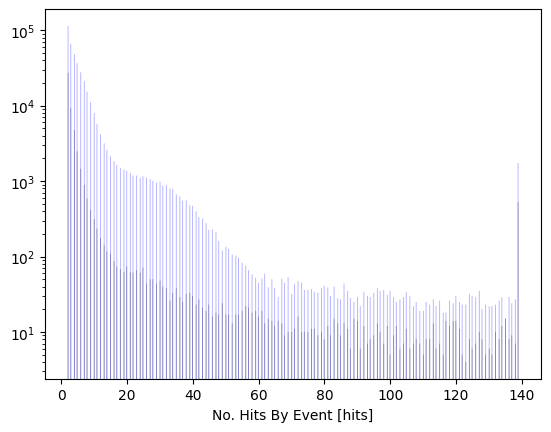

In [14]:
plt.hist(total_nhits_by_event_bkg, 500, histtype="stepfilled", alpha=0.3);
plt.hist(total_nhits_by_event_sig, 500, histtype="stepfilled", alpha=0.3);
plt.xlabel("No. Hits By Event [hits]");
plt.yscale("log");

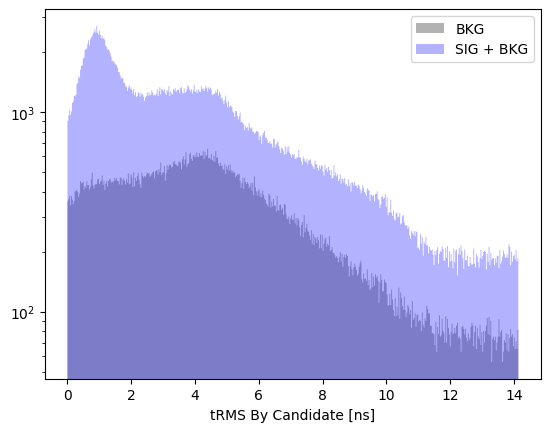

In [11]:
plt.hist(total_trms_by_event_bkg, 500, histtype="stepfilled", alpha=0.3, label="BKG");
plt.hist(total_trms_by_event_sig, 500, histtype="stepfilled", alpha=0.3, label="SIG + BKG");
plt.xlabel("tRMS By Candidate [ns]");
plt.yscale("log");
plt.legend();

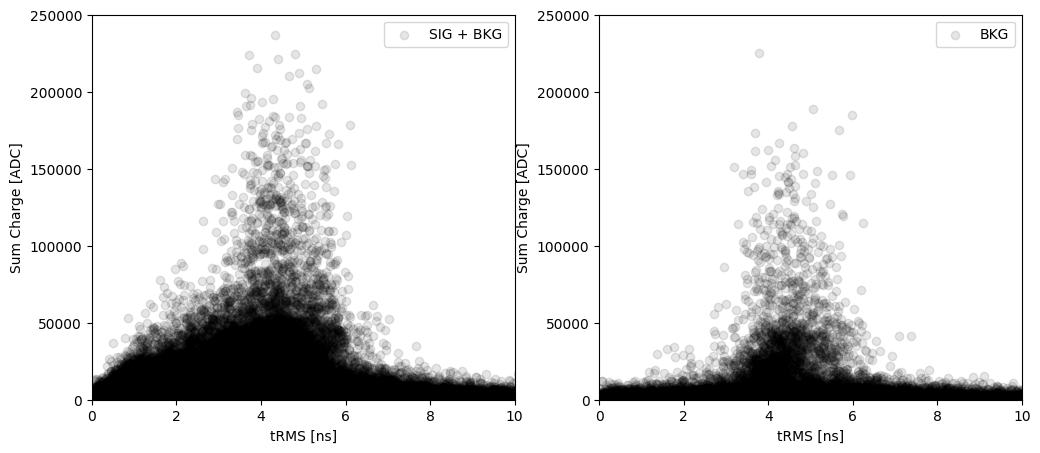

In [15]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_trms_by_event_sig, total_charge_by_event_sig, alpha=0.1, label="SIG + BKG");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);
plt.legend()

subplot(2)
plt.scatter(total_trms_by_event_bkg, total_charge_by_event_bkg, alpha=0.1, label="BKG");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);
plt.legend();

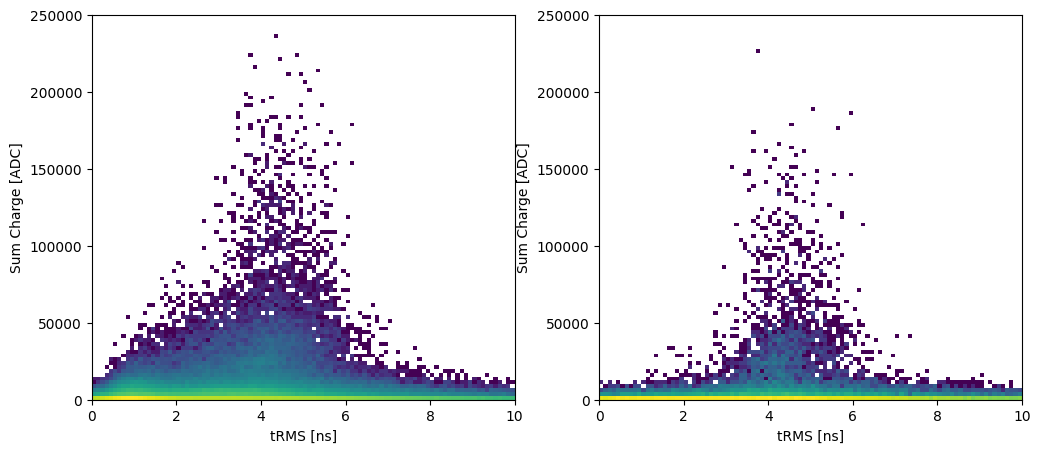

In [16]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);

subplot(2)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);